<b> Rex Orly Mallorca, T09 </b>
<br> Robotics and Intelligent Control Systems Engineering 1

In [60]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models

# Split Dataset

In [84]:
BATCH_SIZE = 32
IMG_SIZE = (128,128)  
DATA_DIR = 'dataset'   
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 506 files belonging to 2 classes.
Using 405 files for training.
Found 506 files belonging to 2 classes.
Using 101 files for validation.


# Model Design

In [85]:
model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [86]:
model.compile(
    optimizer='adam',               
    loss='binary_crossentropy',      
    metrics=['accuracy']             
)

epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.4790 - loss: 0.7857 - val_accuracy: 0.5743 - val_loss: 0.6773
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.5778 - loss: 0.6732 - val_accuracy: 0.6337 - val_loss: 0.6294
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - accuracy: 0.6494 - loss: 0.6427 - val_accuracy: 0.6634 - val_loss: 0.6241
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.6914 - loss: 0.5815 - val_accuracy: 0.7129 - val_loss: 0.5668
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.7457 - loss: 0.5510 - val_accuracy: 0.7822 - val_loss: 0.5199
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.7951 - loss: 0.4640 - val_accuracy: 0.7723 - val_loss: 0.4909
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.8025 - loss: 0.4514 - val_accuracy: 0.7723 - val_loss: 0.5423
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.8420 - loss: 0.3833 - val_accuracy: 0.

# Graphing

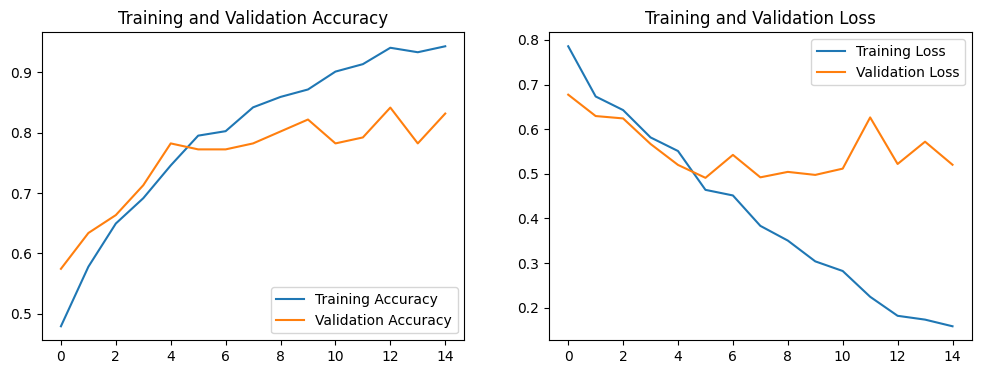

In [87]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Image Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
RESULT: Burger
confidence: 100.00%


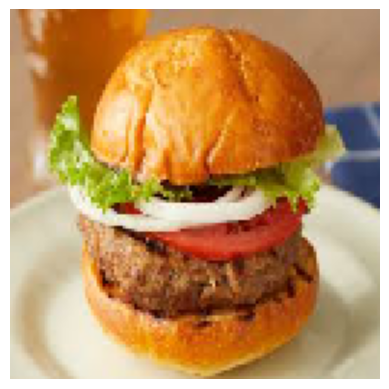

In [88]:
image_path = 'burger.jpg'

img = tf.keras.utils.load_img(
    image_path, target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0) 

img_array = img_array / 255.0

predictions = model.predict(img_array)
score = predictions[0][0]

if score > 0.5:
    print(f"RESULT: Burger")
    print(f"confidence: {100 * score:.2f}%")
else:
    print(f"RESULT: Fries")
    print(f"confidence: {100 * (1 - score):.2f}%")

plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
RESULT: Fries
confidence: 99.70%


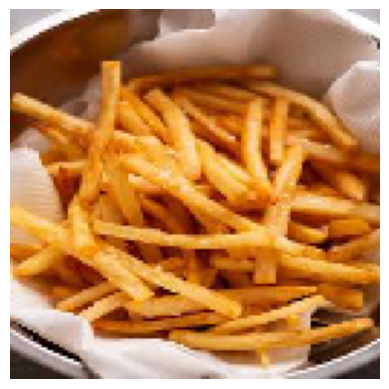

In [89]:
image_path = 'fries.jpg'

img = tf.keras.utils.load_img(
    image_path, target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0) 

img_array = img_array / 255.0

predictions = model.predict(img_array)
score = predictions[0][0]

if score > 0.5:
    print(f"RESULT: Burger")
    print(f"confidence: {100 * score:.2f}%")
else:
    print(f"RESULT: Fries")
    print(f"confidence: {100 * (1 - score):.2f}%")

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
RESULT: Fries
confidence: 81.33%


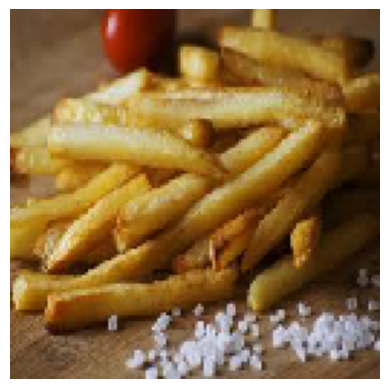

In [90]:
image_path = 'fries2.jpg'

img = tf.keras.utils.load_img(
    image_path, target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0) 

img_array = img_array / 255.0

predictions = model.predict(img_array)
score = predictions[0][0]

if score > 0.5:
    print(f"RESULT: Burger")
    print(f"confidence: {100 * score:.2f}%")
else:
    print(f"RESULT: Fries")
    print(f"confidence: {100 * (1 - score):.2f}%")

plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
RESULT: Burger
confidence: 64.01%


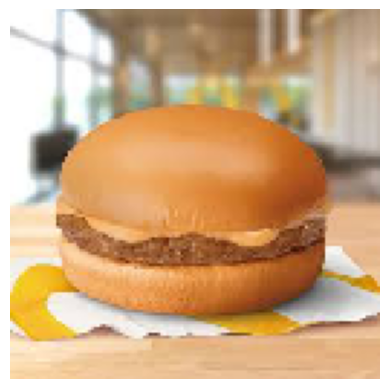

In [91]:
image_path = 'burger2.jpg'

img = tf.keras.utils.load_img(
    image_path, target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0) 

img_array = img_array / 255.0

predictions = model.predict(img_array)
score = predictions[0][0]

if score > 0.5:
    print(f"RESULT: Burger")
    print(f"confidence: {100 * score:.2f}%")
else:
    print(f"RESULT: Fries")
    print(f"confidence: {100 * (1 - score):.2f}%")

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')
plt.show()

# Reflection

<h4> There were two major problems I encountered while making this model. The first issue occurred during the model design stage when the model design became too complex or too high, the training loss also increased significantly. The second problem appeared during prediction testing: the model kept misclassifying the images, predicting burger.jpg as fries and fries.jpg as a burger. At first, I thought the issue was with the training process or the model design itself. In the end, I discovered that the problem was caused by a simple logical error in the code. </h4>